In [ ]:
!pip install xgboost shap -q

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder, StandardScaler

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

from imblearn.over_sampling import SMOTE

from xgboost import XGBClassifier

import joblib

In [ ]:
df = pd.read_csv('/content/stroke.csv')

df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [ ]:
df.drop('id', axis=1, inplace=True)

df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [ ]:
df['bmi'] = df['bmi'].fillna(df['bmi'].median())

In [ ]:
cat_cols = [
    'gender',
    'ever_married',
    'work_type',
    'Residence_type',
    'smoking_status'
]

le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))

In [ ]:
X = df.drop('stroke', axis=1)
y = df['stroke']

In [ ]:
print(y.value_counts())

stroke
0    4861
1     249
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
smote = SMOTE(sampling_strategy=0.5, random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

print(y_train.value_counts())

stroke
0    3889
1    1944
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(972/50),  # important for imbalance
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
thresholds = [0.3, 0.35, 0.4, 0.45]

y_pred = (y_prob > threshold).astype(int)

In [ ]:
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.98      0.74      0.84       972
           1       0.12      0.68      0.20        50

    accuracy                           0.74      1022
   macro avg       0.55      0.71      0.52      1022
weighted avg       0.94      0.74      0.81      1022

ROC-AUC: 0.7874485596707819


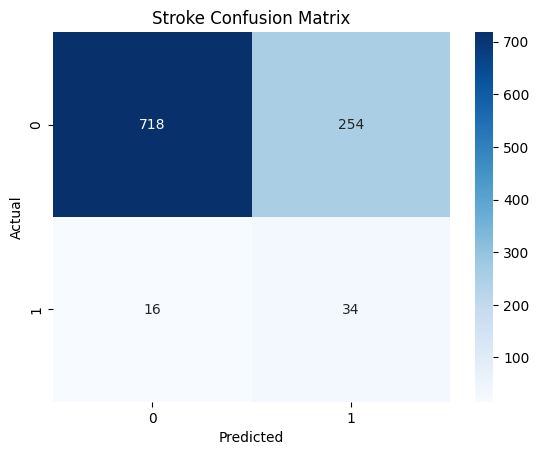

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Stroke Confusion Matrix")
plt.show()

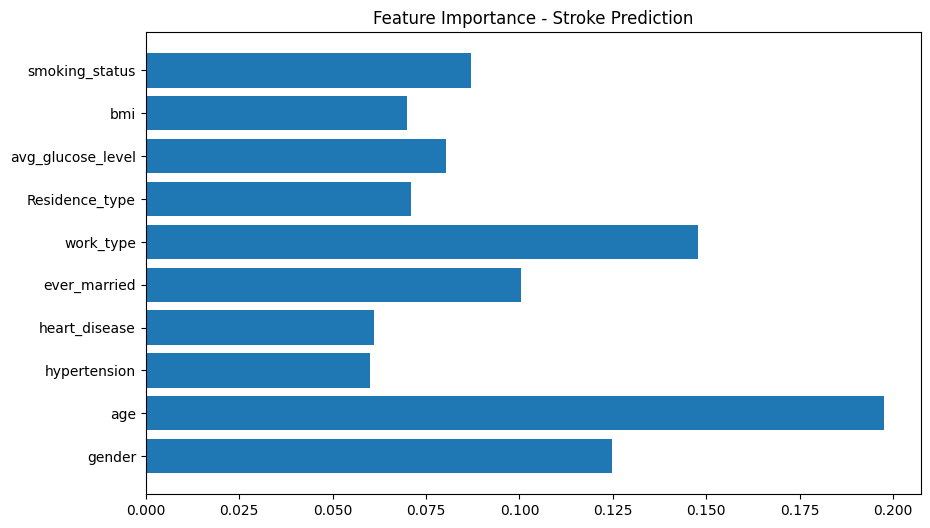

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(X.columns, model.feature_importances_)

plt.title("Feature Importance - Stroke Prediction")
plt.show()

In [ ]:
joblib.dump(model, 'stroke_model.pkl')
joblib.dump(scaler, 'stroke_scaler.pkl')

['stroke_scaler.pkl']

In [ ]:
sample = X_test[0].reshape(1, -1)

prob = model.predict_proba(sample)[0][1]

print("Stroke Risk Probability:", prob)

Stroke Risk Probability: 0.3765634


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import make_scorer, roc_auc_score

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

def run_cv_pipeline(model, X, y, name):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    scores = cross_val_score(
        pipeline,
        X,
        y,
        cv=cv,
        scoring='roc_auc'
    )

    print(f"\n==== {name} ====")
    print("ROC-AUC scores:", scores)
    print("Mean ROC-AUC:", scores.mean())
    print("Std:", scores.std())

In [ ]:
run_cv_pipeline(model, X, y, "stroke")


==== stroke ====
ROC-AUC scores: [0.79759259 0.83139918 0.80261317 0.82541152 0.80904839]
Mean ROC-AUC: 0.8132129698034035
Std: 0.013063219583990976
